# TitanTPP V1/V2 Baseline Analysis

## tl;dr

- V2 (`hybrid`) is the stronger pre-V3 baseline overall, but the reason differs by dataset.
- `intermittent-small_lmm`: V2 improves held-out score by `+0.00773` and quantity MAE by `-9.94%`; all three seeds improve score and quantity MAE.
- `yellow_trip_hourly-mid_lmm`: V2 improves mean score by `+0.01606` and quantity MAE by `-25.86%`, while test NLL worsens by `+1.23%` because marker NLL rises. The quantity gain is not seed-stable: seed 42 regresses.
- `insta_market_basket-small_lmm`: V2 improves score only marginally (`+0.00038`) and quantity MAE by `-1.04%`; the gain is concentrated in the `1-9` quantity bucket.
- V1 taxi training becomes unstable after its early best epoch, while V2 remains stable through epoch 200. Checkpoint selection must remain `best_val_nll`.


## Context & Methods

The decision is which TitanTPP configuration should be locked as the immediate baseline before V3 (mark-conditioned value head).

### Key Assumptions

- Candidate selection uses validation mean best NLL, not held-out test metrics.
- Test interpretation uses the `best_val_nll` checkpoint.
- V1 and V2 differ only in `loss_mode`: V1 is `residual_only`; V2 is `hybrid`.
- A lower NLL, quantity MAE, and delta-time MAE is better; a higher score and mark accuracy is better.
- The experiment includes three seeds (`42`, `52`, `62`) and fixed chronological splits.


## Data

### 1. Load Artifacts

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "search_artifacts").exists()
)
ARTIFACT_ROOT = PROJECT_ROOT / "search_artifacts"
EXPERIMENTS = {
    "V1": ARTIFACT_ROOT / "model_enhancement_v1_residual_e200_0705",
    "V2": ARTIFACT_ROOT / "model_enhancement_v2_hybrid_e200_0705",
}

def load_table(filename):
    frames = []
    for variant, directory in EXPERIMENTS.items():
        frame = pd.read_csv(directory / "leaderboard" / filename)
        frame["variant"] = variant
        frames.append(frame)
    return pd.concat(frames, ignore_index=True)

summary = load_table("summary.csv")
test_summary = load_table("test_summary.csv")
test_metrics = load_table("test_metrics.csv")
histories = load_table("histories.csv")
test_scales = load_table("test_scale_wise_summary.csv")

summary.shape, test_summary.shape, histories.shape

Matplotlib is building the font cache; this may take a moment.


((12, 33), (36, 19), (7200, 15))

### 2. Validate Inputs

In [2]:
manifests = {
    variant: json.loads((directory / "experiment_manifest.json").read_text())
    for variant, directory in EXPERIMENTS.items()
}

v1_config = manifests["V1"]["experiment_config"].copy()
v2_config = manifests["V2"]["experiment_config"].copy()
for key in ["base_dir", "loss_mode"]:
    v1_config.pop(key)
    v2_config.pop(key)

assert v1_config == v2_config
assert manifests["V1"]["experiment_config"]["loss_mode"] == "residual_only"
assert manifests["V2"]["experiment_config"]["loss_mode"] == "hybrid"
assert set(summary["run_count"]) == {3}
assert len(histories) == 2 * 3 * 2 * 3 * 200

pd.DataFrame(
    {
        "variant": ["V1", "V2"],
        "loss_mode": ["residual_only", "hybrid"],
        "completed_runs": [18, 18],
        "history_rows": [len(histories[histories.variant == "V1"]), len(histories[histories.variant == "V2"])],
    }
)

,variant,loss_mode,completed_runs,history_rows
0,V1,residual_only,18,3600
1,V2,hybrid,18,3600


## Results

### 3. Select Candidates Using Validation Only

In [3]:
selected_candidates = (
    summary.sort_values(
        ["variant", "dataset_name", "mean_best_val_nll", "candidate_name"]
    )
    .groupby(["variant", "dataset_name"], as_index=False)
    .first()[["variant", "dataset_name", "candidate_name", "mean_best_val_nll"]]
)
selected_candidates

,variant,dataset_name,candidate_name,mean_best_val_nll
0,V1,insta_market_basket,mid_lmm,4.379298
1,V1,intermittent,small_lmm,5.629190
2,V1,yellow_trip_hourly,small_lmm,1.568134
3,V2,insta_market_basket,small_lmm,4.381901
4,V2,intermittent,small_lmm,5.604595
5,V2,yellow_trip_hourly,mid_lmm,1.576568


### 4. Compare Held-out Test Metrics

In [4]:
selected_test = test_summary.merge(
    selected_candidates[["variant", "dataset_name", "candidate_name"]],
    on=["variant", "dataset_name", "candidate_name"],
    how="inner",
)
selected_test = selected_test[selected_test["selection"] == "best_val_nll"].copy()

display_columns = [
    "variant", "dataset_name", "candidate_name", "mean_test_score",
    "mean_test_nll", "mean_test_nll_marker", "mean_test_nll_time",
    "mean_test_qty_mae", "mean_test_dt_mae", "mean_test_mark_acc",
]
selected_test[display_columns].sort_values(["dataset_name", "variant"])

,variant,dataset_name,candidate_name,mean_test_score,mean_test_nll,mean_test_nll_marker,mean_test_nll_time,mean_test_qty_mae,mean_test_dt_mae,mean_test_mark_acc
1,V1,insta_market_basket,mid_lmm,0.436657,4.461641,1.162302,3.299339,4.452236,6.229942,0.503409
10,V2,insta_market_basket,small_lmm,0.437034,4.463426,1.163331,3.300095,4.405873,6.224413,0.503684
4,V1,intermittent,small_lmm,0.279412,5.057966,1.007608,4.050358,3.365281,25.289885,0.535676
13,V2,intermittent,small_lmm,0.287139,5.041964,1.003391,4.038573,3.030658,25.089212,0.541062
7,V1,yellow_trip_hourly,small_lmm,0.824321,1.630693,0.222141,1.408552,79.172297,0.819953,0.911693
16,V2,yellow_trip_hourly,mid_lmm,0.840379,1.650796,0.251394,1.399403,58.700291,0.785006,0.906929


In [5]:
metric_columns = [
    "mean_test_score", "mean_test_nll", "mean_test_nll_marker",
    "mean_test_nll_time", "mean_test_qty_mae", "mean_test_dt_mae",
    "mean_test_mark_acc",
]
v1 = selected_test[selected_test.variant == "V1"].set_index("dataset_name")
v2 = selected_test[selected_test.variant == "V2"].set_index("dataset_name")
deltas = pd.DataFrame(index=sorted(set(v1.index) & set(v2.index)))
deltas["v1_candidate"] = v1.loc[deltas.index, "candidate_name"]
deltas["v2_candidate"] = v2.loc[deltas.index, "candidate_name"]
for column in metric_columns:
    deltas[f"delta_{column}"] = v2.loc[deltas.index, column] - v1.loc[deltas.index, column]

deltas["qty_mae_change_pct"] = (
    100 * deltas["delta_mean_test_qty_mae"] / v1.loc[deltas.index, "mean_test_qty_mae"]
)
deltas["nll_change_pct"] = (
    100 * deltas["delta_mean_test_nll"] / v1.loc[deltas.index, "mean_test_nll"]
)
deltas.reset_index().rename(columns={"index": "dataset_name"})

,dataset_name,v1_candidate,v2_candidate,delta_mean_test_score,delta_mean_test_nll,delta_mean_test_nll_marker,delta_mean_test_nll_time,delta_mean_test_qty_mae,delta_mean_test_dt_mae,delta_mean_test_mark_acc,qty_mae_change_pct,nll_change_pct
0,insta_market_basket,mid_lmm,small_lmm,0.000377,0.001785,0.001029,0.000756,-0.046363,-0.005529,0.000275,-1.041350,0.040012
1,intermittent,small_lmm,small_lmm,0.007727,-0.016002,-0.004217,-0.011785,-0.334622,-0.200673,0.005386,-9.943375,-0.316370
2,yellow_trip_hourly,small_lmm,mid_lmm,0.016058,0.020103,0.029252,-0.009150,-20.472005,-0.034947,-0.004764,-25.857536,1.232774


### 5. Check Paired Seed Consistency

In [6]:
selected_seed_metrics = test_metrics.merge(
    selected_candidates[["variant", "dataset_name", "candidate_name"]],
    on=["variant", "dataset_name", "candidate_name"],
    how="inner",
)
selected_seed_metrics = selected_seed_metrics[
    selected_seed_metrics["selection"] == "best_val_nll"
]
paired = selected_seed_metrics.pivot(
    index=["dataset_name", "seed"],
    columns="variant",
    values=["score", "qty_mae", "val_nll", "mark_acc", "dt_mae"],
)
paired_deltas = pd.DataFrame(index=paired.index)
for column in ["score", "qty_mae", "val_nll", "mark_acc", "dt_mae"]:
    paired_deltas[f"delta_{column}"] = paired[(column, "V2")] - paired[(column, "V1")]
paired_deltas.reset_index()

,dataset_name,seed,delta_score,delta_qty_mae,delta_val_nll,delta_mark_acc,delta_dt_mae
0,insta_market_basket,42,0.000797,-0.050794,-0.002517,0.000735,-0.001169
1,insta_market_basket,52,0.000049,-0.050571,0.007237,0.000199,0.020076
2,insta_market_basket,62,0.000285,-0.037725,0.000635,-0.000107,-0.035493
3,intermittent,42,0.009992,-0.338210,0.001153,0.009651,-0.000292
4,intermittent,52,0.008934,-0.369355,-0.007787,0.005394,-0.317078
5,intermittent,62,0.004255,-0.296303,-0.041372,0.001113,-0.284648
6,yellow_trip_hourly,42,-0.003705,3.296228,0.022494,-0.000961,-0.055242
7,yellow_trip_hourly,52,0.040867,-40.590504,0.005951,-0.000240,-0.051639
8,yellow_trip_hourly,62,0.011011,-24.121739,0.031863,-0.013090,0.002040


### 6. Diagnose Convergence and Overfitting

In [7]:
history_rows = []
for (variant, dataset, candidate, seed), group in histories.groupby(
    ["variant", "dataset_name", "candidate_name", "seed"]
):
    best = group.loc[group["val_nll"].idxmin()]
    final = group.loc[group["epoch"].idxmax()]
    history_rows.append(
        {
            "variant": variant,
            "dataset_name": dataset,
            "candidate_name": candidate,
            "seed": seed,
            "best_nll_epoch": int(best["epoch"]),
            "best_val_nll": best["val_nll"],
            "final_val_nll": final["val_nll"],
            "final_minus_best_nll": final["val_nll"] - best["val_nll"],
        }
    )
history_diagnostics = pd.DataFrame(history_rows).merge(
    selected_candidates[["variant", "dataset_name", "candidate_name"]],
    on=["variant", "dataset_name", "candidate_name"],
    how="inner",
)
history_diagnostics.sort_values(["dataset_name", "variant", "seed"])

,variant,dataset_name,candidate_name,seed,best_nll_epoch,best_val_nll,final_val_nll,final_minus_best_nll
0,V1,insta_market_basket,mid_lmm,42,91,4.380951,4.391382,0.010431
1,V1,insta_market_basket,mid_lmm,52,163,4.379258,4.398371,0.019113
2,V1,insta_market_basket,mid_lmm,62,131,4.377684,4.398131,0.020446
9,V2,insta_market_basket,small_lmm,42,20,4.380851,4.402252,0.021401
10,V2,insta_market_basket,small_lmm,52,112,4.382183,4.398893,0.016710
11,V2,insta_market_basket,small_lmm,62,24,4.382669,4.397816,0.015147
3,V1,intermittent,small_lmm,42,13,5.605730,5.782470,0.176740
4,V1,intermittent,small_lmm,52,25,5.626924,5.768843,0.141919
5,V1,intermittent,small_lmm,62,24,5.654918,5.806415,0.151498
12,V2,intermittent,small_lmm,42,27,5.614595,5.825627,0.211032


### 7. Compare Test Quantity Error by Scale

In [8]:
selected_scales = test_scales.merge(
    selected_candidates[["variant", "dataset_name", "candidate_name"]],
    on=["variant", "dataset_name", "candidate_name"],
    how="inner",
)
selected_scales = selected_scales[
    (selected_scales["selection"] == "best_val_nll")
    & (selected_scales["total_count"] > 0)
]
scale_comparison = selected_scales.pivot(
    index=["dataset_name", "scale_order", "scale_label", "mean_share"],
    columns="variant",
    values="mean_qty_mae",
).reset_index()
scale_comparison["delta_qty_mae"] = scale_comparison["V2"] - scale_comparison["V1"]
scale_comparison["delta_qty_mae_pct"] = (
    100 * scale_comparison["delta_qty_mae"] / scale_comparison["V1"]
)
scale_comparison

variant,dataset_name,scale_order,scale_label,mean_share,V1,V2,delta_qty_mae,delta_qty_mae_pct
0,insta_market_basket,0,1-9,0.531488,3.330480,3.168268,-0.162213,-4.870546
1,insta_market_basket,1,10-99,0.468475,5.719871,5.803841,0.083970,1.468037
2,insta_market_basket,2,100-999,0.000036,69.043933,83.171390,14.127457,20.461547
3,intermittent,0,1-9,0.886658,1.173038,1.081450,-0.091588,-7.807767
4,intermittent,1,10-99,0.106593,9.862773,9.246621,-0.616151,-6.247244
5,intermittent,2,100-999,0.005829,124.996339,104.536043,-20.460296,-16.368717
6,intermittent,3,1000-9999,0.000919,593.251904,518.754962,-74.496943,-12.557388
7,yellow_trip_hourly,0,1-9,0.542332,1.974375,1.699035,-0.275339,-13.945657
8,yellow_trip_hourly,1,10-99,0.243305,17.528769,15.759181,-1.769588,-10.095336
9,yellow_trip_hourly,2,100-999,0.138946,202.946421,131.779727,-71.166694,-35.066740


### 8. Visualize Decision Metrics

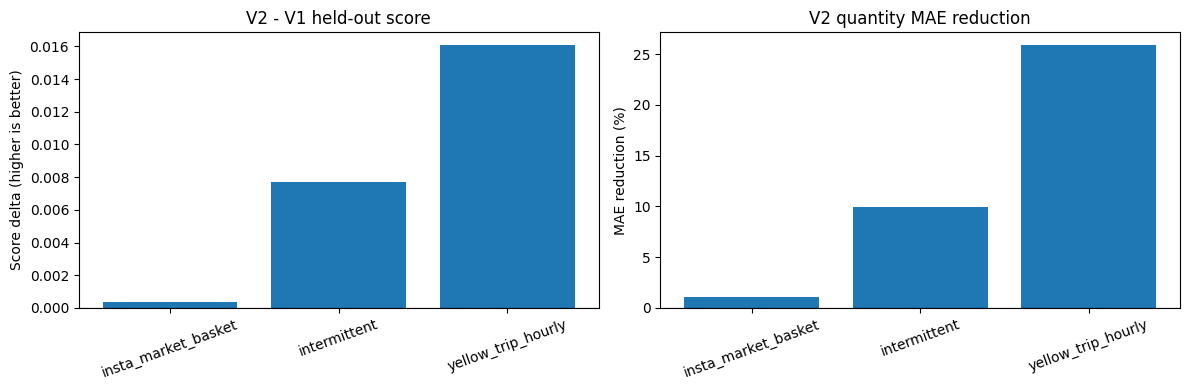

In [9]:
plot_data = deltas.reset_index().rename(columns={"index": "dataset_name"})
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(plot_data["dataset_name"], plot_data["delta_mean_test_score"])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("V2 - V1 held-out score")
axes[0].set_ylabel("Score delta (higher is better)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(plot_data["dataset_name"], -plot_data["qty_mae_change_pct"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("V2 quantity MAE reduction")
axes[1].set_ylabel("MAE reduction (%)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Takeaways

1. **Lock V2 as the primary pre-V3 baseline.** Use `small_lmm` for `intermittent` and `insta_market_basket`, and `mid_lmm` for `yellow_trip_hourly`. These candidates were selected using validation NLL only.
2. **Keep V1 as a probabilistic-head guardrail.** Taxi V2 trades a `1.23%` NLL increase and lower mark accuracy for a `25.86%` quantity MAE reduction. V3 should aim to retain the quantity gain while recovering marker NLL and mark accuracy.
3. **Treat taxi evidence as promising but not fully stable.** Two of three seeds improve strongly, while seed 42 regresses in score and quantity MAE. More seeds or `lambda_qty` tuning are needed before claiming a robust taxi gain.
4. **Intermittent is the strongest positive result.** V2 improves quantity MAE in every populated scale bucket and improves score/quantity in all three seeds.
5. **Instacart remains near a plateau.** The aggregate gain is small and concentrated in the `1-9` bucket; the `10-99` bucket worsens slightly, and the `100-999` bucket is too rare to support a stable claim.
6. **Always evaluate saved checkpoints.** V1 taxi final-epoch NLL collapses after the early optimum, especially for `mid_lmm`; `best_val_nll` checkpointing is essential.
